# Technical Signal Discovery in Daily OHLCV Data
### A Walk-Forward Comparison with Reversal and Momentum

Ritvik Verma &middot; Tate Gilbertson &middot; Neel Padhye &middot; Ahmad Mohammad
&mdash; FINM 33100, Summer 2026

This notebook walks through the same pipeline behind **`Report/main.pdf`** and
reproduces its tables and figures. It compares a simple 3-feature reversal/momentum
baseline against a broad library of 90 Kakushadze formulaic alphas + 15 classic
OHLCV signals, at 1-day and 5-day horizons, under yearly walk-forward validation
(2013-2025 test years).

**Two speeds, both real code, no shortcuts on the numbers:**
- Sections 1-5 run live against a **small subset** of the panel (a few hundred
  names, a handful of years) so every step below actually executes in seconds
  using the project's real `src/` functions — not a toy reimplementation.
- Section 6 onward loads the committed, full-scale results under `outputs/`
  (the same artifacts `Report/main.tex` cites) and reproduces the paper's exact
  tables and figures. The raw walk-forward predictions those came from
  (`outputs/model_runs/*__preds.parquet`) are too large to commit to git, so a
  full from-scratch regeneration of Sections 6-8's numbers means rerunning
  `run_models.py` first (~40+ minutes on the full universe) — see the
  **Reproducibility** section at the very end for those exact commands.

**Requirements:** `data/olhcv_merged.parquet` on disk (course-provided, not
committed to git). Kernel: `FINM 33100 Group 2 (Python 3.13)` (see `README.md`
for the `uv run python -m ipykernel install` setup command).

## 1. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("data/olhcv_merged.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. This notebook needs the course OHLCV parquet "
        "on disk at that path -- see README.md's Setup section."
    )
print(f"Found {DATA_PATH} ({DATA_PATH.stat().st_size / 1e6:.0f} MB)")

Found data/olhcv_merged.parquet (285 MB)


## 2. Data and prediction targets (live, small-scale)

`src/data.py` loads the panel keyed on CRSP `permno` (never `ticker`, which is
reused across securities over 25 years). Forward returns are the *only* legal
target -- the panel's `ret` field is backward-looking.

The call order is `load_panel` &rarr; `build_forward_return_targets` &rarr;
`prepare_panel`: `prepare_panel` moves `permno`/`date` into the index, and
`build_forward_return_targets` needs them as plain columns, so targets are
built first.

We use a small subset here (`top_n=150` names by market cap, last 6 years) purely
so this cell runs in seconds -- the full-universe, full-history numbers are in
`outputs/panel_audit.json`, loaded right after.

In [2]:
from src.data import load_panel, build_forward_return_targets
from src.signals import prepare_panel

raw = load_panel(top_n=150, lookback_years=6)
with_targets = build_forward_return_targets(raw, horizons=(1, 5))
panel_demo = prepare_panel(with_targets)

print(f"raw panel: {raw.shape}")
print(f"date range: {raw['date'].min().date()} .. {raw['date'].max().date()}")
panel_demo.reset_index()[["permno", "date", "close", "fwd_ret_1d", "fwd_ret_5d"]].head(8)

load_panel: dropped 1,180 rows missing mcap/close (0.019% of panel)


raw panel: (226200, 14)
date range: 2020-01-02 .. 2025-12-31


,permno,date,close,fwd_ret_1d,fwd_ret_5d
0,10104,2020-01-02,53.95,-0.003522,0.00797
1,10104,2020-01-03,53.76,0.005208,0.012835
2,10104,2020-01-06,54.04,0.002221,0.009993
3,10104,2020-01-07,54.16,-0.000554,0.013294
4,10104,2020-01-08,54.13,0.004619,0.011639
5,10104,2020-01-09,54.38,0.001287,0.019309
6,10104,2020-01-10,54.45,0.002388,0.012489
7,10104,2020-01-13,54.58,0.005497,0.011726


In [3]:
# segment_id demo: a >10-calendar-day gap starts a new listing segment, so
# rolling features/targets never blend an exit with a later re-entry.
seg_counts = panel_demo.reset_index().groupby("permno")["segment_id"].nunique()
multi_segment = seg_counts[seg_counts > 1]
print(f"{len(multi_segment)} / {len(seg_counts)} names in this subset have a gap-driven re-entry")
multi_segment.head()

127 / 263 names in this subset have a gap-driven re-entry


permno
10516    2
11403    3
11990    5
12052    2
12369    8
Name: segment_id, dtype: int64

Full-universe panel audit (2001-2025, all securities) -- the numbers behind the report's Appendix A table:

In [4]:
import json

audit = json.loads(Path("outputs/panel_audit.json").read_text())
summary_keys = [
    "n_rows", "n_permno", "n_dates", "date_min", "date_max",
    "names_per_day_min", "names_per_day_median", "names_per_day_max",
    "dup_permno_date", "n_segments", "n_long_gaps", "target_nan_share",
]
pd.Series({k: audit[k] for k in summary_keys}, name="value").to_frame()

,value
n_rows,6253895
n_permno,3253
n_dates,6266
date_min,2001-02-01
date_max,2025-12-31
names_per_day_min,988
names_per_day_median,998.0
names_per_day_max,1000
dup_permno_date,0
n_segments,8748


In [5]:
print("ret vs. close-to-close price return (should be tiny for almost all rows):")
print(audit["ret_vs_price_return"])

ret vs. close-to-close price return (should be tiny for almost all rows):
{'n': 6245147, 'median_abs': 2.4937531237093427e-07, 'p99_abs': 5.496335775088956e-07, 'share_lt_1e8': 0.03314861923986737, 'share_lt_1e4': 0.9902016717941147}


## 3. Feature library (live, small-scale)

Three feature groups, all built from the same prepared panel:
- **Baseline** (3 features, never changed): 1-day reversal, 5-day reversal, 12-1 momentum.
- **90 formulaic alphas** from Kakushadze (2015), of the 101 published. Skipped:
  48, 67, 90, 100 (need subindustry, we only have `sic2`=industry), 58, 76, 79
  (need sector), and 59, 66, 82, 89 (reduce to identities).
- **15 classic OHLCV features**: intraday price shape, reversal/momentum at other
  lookbacks, volatility, unusual volume, Amihud illiquidity, distance from the
  52-week high.

In [6]:
from src.signals import build_baseline_features
from src.signals.alphas import build_alpha_features
from src.signals.classic_features import build_classic_features

baseline_demo = build_baseline_features(panel_demo)
alpha_demo = build_alpha_features(panel_demo)
classic_demo = build_classic_features(panel_demo)

print(f"baseline features: {baseline_demo.shape[1]} columns -> {list(baseline_demo.columns)}")
print(f"alpha features: {alpha_demo.shape[1]} columns")
print(f"classic features: {classic_demo.shape[1]} columns -> {list(classic_demo.columns)}")
print(f"candidate technical pool (alphas + classic): {alpha_demo.shape[1] + classic_demo.shape[1]} columns")

baseline features: 7 columns -> ['close', 'rev_1d', 'rev_5d', 'mom_12_1', 'rev_1d_x_rev_5d', 'rev_1d_x_mom_12_1', 'rev_5d_x_mom_12_1']
alpha features: 90 columns
classic features: 15 columns -> ['oc_ret', 'hl_range', 'overnight_gap', 'close_loc', 'ret_21d', 'mom_63', 'mom_6_1', 'vol_21d', 'parkinson_vol_21d', 'vol_of_vol_63d', 'vol_vs_mean21', 'dollar_vol_rank', 'amihud_21d', 'dist_52wk_high', 'max_ret_21d']
candidate technical pool (alphas + classic): 105 columns


In [7]:
alpha_demo[["alpha_001", "alpha_003", "alpha_012", "alpha_101"]].describe().T

,count,mean,std,min,25%,50%,75%,max
alpha_001,215699.0,0.003486,0.265146,-0.493197,-0.234043,-0.02069,0.239726,0.5
alpha_003,215500.0,-1.390486,22.345659,-1000.0,-0.279127,0.020333,0.325891,269.407953
alpha_012,225444.0,0.188646,7.842229,-452.17,-1.23,0.06,1.45,396.03
alpha_101,226200.0,0.018866,0.521054,-0.999985,-0.431426,0.028754,0.472026,0.99999


## 4. Target-blind correlation pruning

The candidate pool (105 alpha+classic columns) is pruned once, target-blind, on
**2001-2010** -- years that are never used for training, validation, or test in
any model below. This uses the full universe (not a daily top-500/150 cut),
so we load the real, already-computed result from `configs/pruned_features.json`
rather than recomputing it on our small demo subset.

Method: drop any feature with &lt;20% finite coverage (103 candidates remain),
then greedily drop one side of the most-correlated pair (mean daily
cross-sectional Spearman &rho;, averaged over 2001-2010) until every remaining
pair has |&rho;| &lt; 0.7.

In [8]:
pruned = json.loads(Path("configs/pruned_features.json").read_text())
print(f"freeze years: {pruned['start_year']}-{pruned['end_year']} (top_n={pruned['top_n']})")
print(f"low-coverage dropped: {pruned['low_coverage_dropped']}")
print(f"threshold {pruned['threshold']}: keep {pruned['n_keep']} of "
      f"{pruned['n_keep'] + len(pruned['dropped'])} features")
print("sensitivity:", {k: v["n_keep"] for k, v in pruned["sensitivity"].items()})

freeze years: 2001-2010 (top_n=None)
low-coverage dropped: ['alpha_096', 'alpha_097']
threshold 0.7: keep 85 of 103 features
sensitivity: {'0.6': 76, '0.7': 85, '0.8': 92}


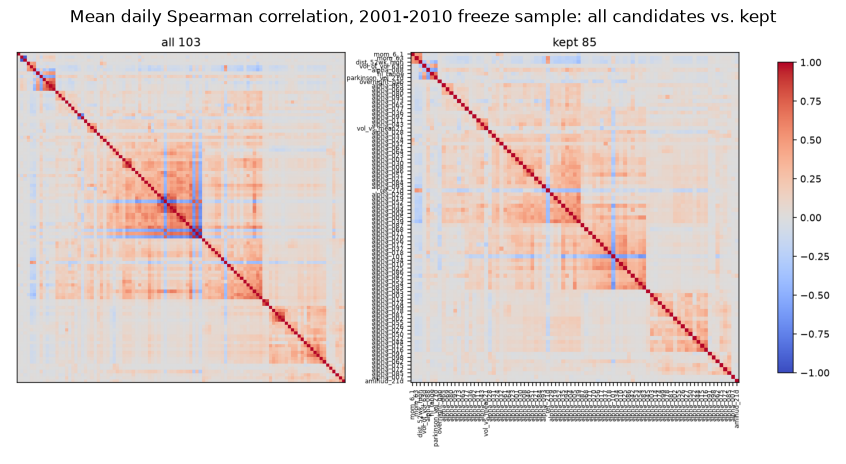

In [9]:
from matplotlib.image import imread

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.imshow(imread("outputs/report/prune_corr.png"))
ax.axis("off")
ax.set_title("Mean daily Spearman correlation, 2001-2010 freeze sample: all candidates vs. kept")
plt.show()

## 5. Model specifications and walk-forward design

| Label | Name | Predictors |
|---|---|---|
| A | Baseline | 1-day reversal, 5-day reversal, 12-1 momentum |
| B | Baseline + interactions | Baseline plus its 3 pairwise rank products |
| C | Pruned technicals | 85 features retained by the frozen correlation filter |
| D | Full technicals | 103 features surviving the coverage screen |

All four are fit separately at 1-day and 5-day horizons with an **elastic net**
(`(alpha, l1_ratio)` chosen on a validation year, refit on train+validation,
evaluated once on the test year), under **yearly walk-forward**: for test year
`Y`, train uses model-sample years before `Y-1`, validate on `Y-1`, test on `Y`,
with a 5-day purge so a 5-day target can't cross a block boundary. First test
year 2013, last 2025.

### Toy demonstration (small subset, illustrative only)

This runs the *actual* `src.models` pipeline -- `get_feature_configs`,
`rank_normalize_features`, `run_one` (which calls `yearly_walk_forward` under
the hood) -- on our small 150-name, 6-year subset, with a single test year, so
the walk-forward + elastic-net mechanics execute end to end in seconds.
Scoring uses `src.scorecard.score_one_run` and `plot_ic_by_year`.

**These numbers are not the report's results** (tiny universe, one test year,
no purge-relevant history) -- they only demonstrate that the same code path
that produced Section 6's real numbers runs correctly.

a_baseline      3 features  test_year=2025  n=37259  by-year mean IC=+0.0056


c_pruned       85 features  test_year=2025  n=37259  by-year mean IC=+0.0192


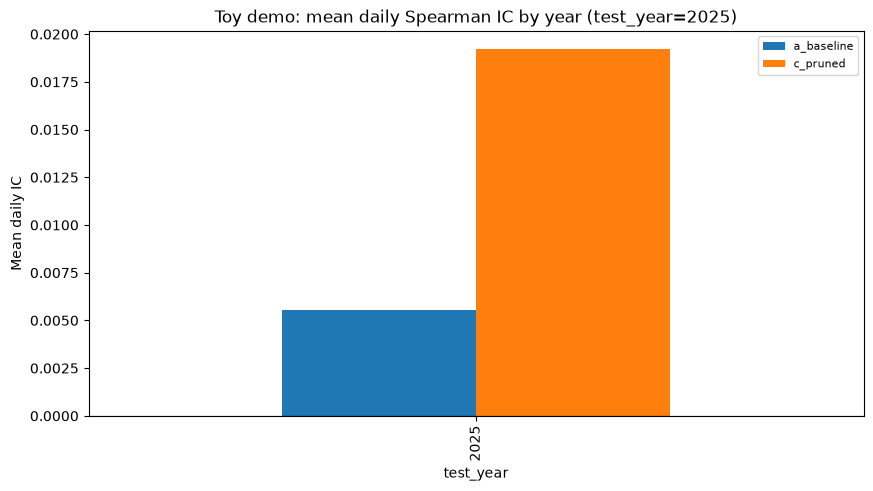

In [10]:
from src.models import get_feature_configs, load_pruned_keep, rank_normalize_features, run_one
from src.scorecard import plot_ic_by_year, score_one_run

demo_frame = pd.concat(
    [baseline_demo.drop(columns="close", errors="ignore"), alpha_demo, classic_demo,
     panel_demo[["fwd_ret_1d"]]],
    axis=1,
).reset_index()

pruned_keep = load_pruned_keep()
pool_cols = [c for c in demo_frame.columns
             if c not in {"permno", "segment_id", "date", "fwd_ret_1d"}
             and c not in {"rev_1d", "rev_5d", "mom_12_1"}]
pruned_keep_in_demo = [c for c in pruned_keep if c in pool_cols]
configs_demo = get_feature_configs(pool_cols, pruned_keep_in_demo)

demo_test_year = int(demo_frame["date"].dt.year.max())
demo_frame_norm = rank_normalize_features(
    demo_frame, sorted({c for cols in configs_demo.values() for c in cols})
)

toy_runs = {}
for name in ["a_baseline", "c_pruned"]:
    out = run_one(
        demo_frame_norm, configs_demo[name], "fwd_ret_1d",
        min_test_year=demo_test_year, max_test_year=demo_test_year,
        val_years=1, purge_days=5,
    )
    toy_runs[name] = score_one_run(out["preds"], horizon=1)
    stats = toy_runs[name]["ic_stats"]
    print(f"{name:12s}  {len(configs_demo[name]):3d} features  test_year={demo_test_year}  "
          f"n={len(out['preds']):5d}  by-year mean IC={stats['mean_ic']:+.4f}")

fig = plot_ic_by_year(toy_runs, title=f"Toy demo: mean daily Spearman IC by year (test_year={demo_test_year})")
plt.show()

## 6. Full-scale results (2013-2025, all 3,253 securities)

From here on we load and plot the committed artifacts under `outputs/report/`
and `outputs/model_runs/` -- the same files `Report/main.tex` cites -- rather
than the demo subset above. Figures call `run_report_figures.py`'s plotting
functions directly.

In [11]:
import run_report_figures as rrf

REPORT_DIR = rrf.OUT_DIR

### 6.1 Main comparison table (reproduces `tab:comparison`)

In [12]:
comparison = pd.read_csv(REPORT_DIR / "model_comparison.csv")
table = comparison.assign(
    Specification=lambda d: d["config"].map(rrf.CONFIGS),
    h=lambda d: d["horizon"].astype(str) + "d",
    **{
        "Active IC": lambda d: d["mean_ic_active"].round(4),
        "Active": lambda d: d["n_active_years"].astype(str) + "/13",
        "All-fold IC": lambda d: d["mean_ic_all_years_null_as_zero"].round(4),
        "Spread (bp)": lambda d: d["mean_long_short_bps_100pct_gross"].round(2),
        "Sharpe": lambda d: d["gross_sharpe"].round(2),
    },
)[["Specification", "h", "Active IC", "Active", "All-fold IC", "Spread (bp)", "Sharpe"]]
table

,Specification,h,Active IC,Active,All-fold IC,Spread (bp),Sharpe
0,Baseline,1d,0.0102,8/13,0.0063,0.27,0.08
1,Baseline,5d,0.0052,8/13,0.0032,-1.90,-0.12
2,Baseline + interactions,1d,0.0109,9/13,0.0076,0.41,0.13
3,Baseline + interactions,5d,0.0052,8/13,0.0032,-0.85,-0.05
4,Pruned technicals,1d,0.0079,10/13,0.0061,1.56,0.63
5,Pruned technicals,5d,0.0041,10/13,0.0032,1.78,0.12
6,Full technicals,1d,0.0081,10/13,0.0062,1.52,0.61
7,Full technicals,5d,0.0042,9/13,0.0029,1.67,0.11


### 6.2 IC by year (reproduces Figure `fig:yearly`)

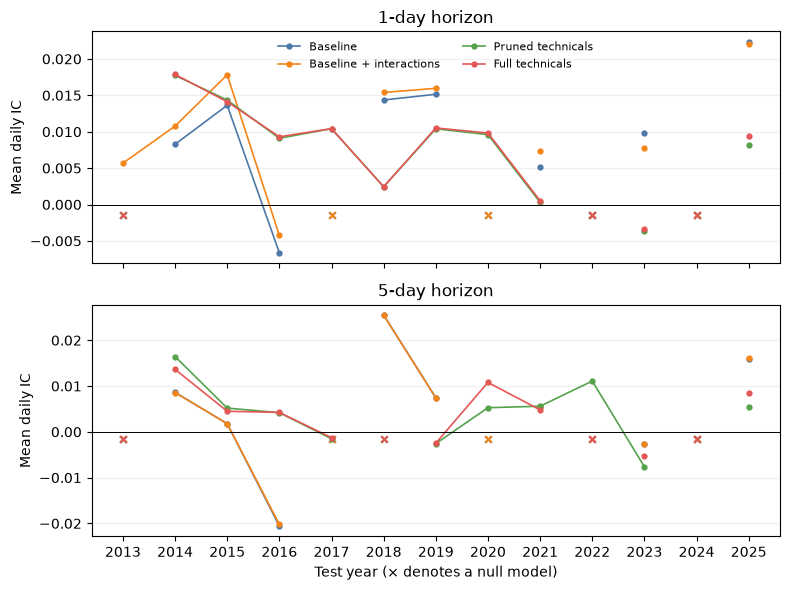

In [13]:
yearly_ic = pd.read_csv(REPORT_DIR / "yearly_ic.csv")
rrf._plot_yearly_ic(yearly_ic, notebook_mode=True)

### 6.3 Decile portfolio profiles (reproduces Figure `fig:deciles`)

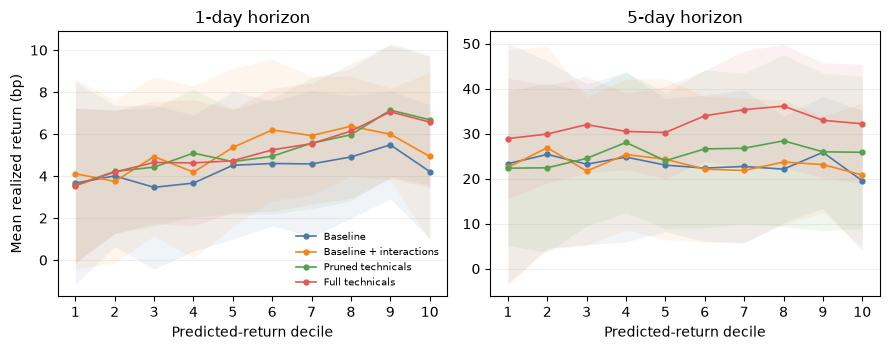

In [14]:
deciles = pd.read_csv(REPORT_DIR / "decile_profiles.csv")
rrf._plot_decile_profiles(deciles, notebook_mode=True)

### 6.4 Coefficient stability, pruned technical model (reproduces Figure `fig:coefs`)

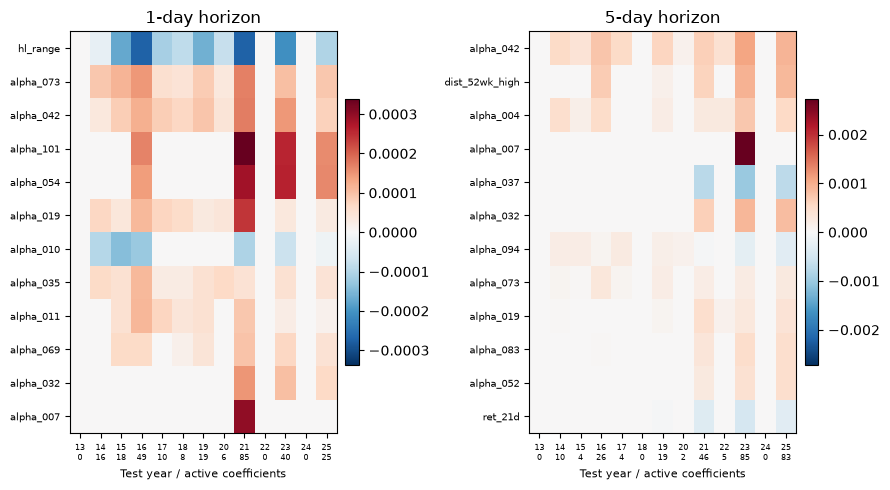

In [15]:
coef_stability = rrf._plot_coefficient_stability(notebook_mode=True)

### 6.5 Tuning diagnostics (reproduces Figure `fig:tuning`)

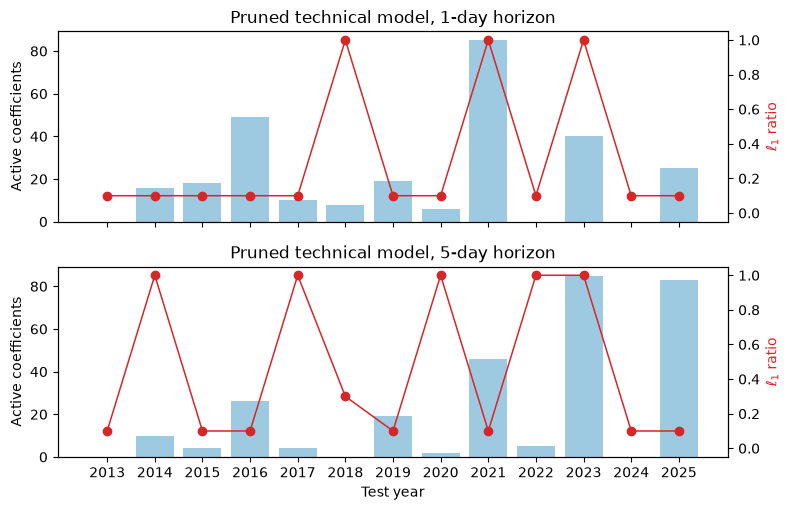

In [16]:
tuning = rrf._plot_tuning_complexity(notebook_mode=True)

## 7. Normalization ablation (reproduces `tab:normalization`)

The default pipeline rank-normalizes every feature per date. This ablation
refits the baseline, pruned, and full-pool 1-day models after within-fold
winsorize + `StandardScaler` instead, and compares only years where both
versions are active.

In [17]:
ablation = pd.read_csv("outputs/ablation_normalization/summary.csv")
ablation_table = ablation.assign(
    Specification=lambda d: d["config"].map(rrf.CONFIGS),
    **{
        "Rank IC": lambda d: d["daily_spearman_ic__paired_rank"].round(4),
        "Standardized IC": lambda d: d["daily_spearman_ic__paired_standardize"].round(4),
        "Delta": lambda d: d["daily_spearman_ic__paired_delta_std_minus_rank"].round(4),
        "Paired years": lambda d: d["daily_spearman_ic__n_paired_years"],
    },
)[["Specification", "Rank IC", "Standardized IC", "Delta", "Paired years"]]
ablation_table

,Specification,Rank IC,Standardized IC,Delta,Paired years
0,Baseline,0.0087,0.0109,0.0022,5
1,Pruned technicals,0.0091,0.0035,-0.0057,7
2,Full technicals,0.0092,0.0034,-0.0058,7


## 8. Stress years and 5-day formation-offset sensitivity (Appendices D-E)

In [18]:
stress = pd.read_csv(REPORT_DIR / "stress_years.csv")
stress_table = stress.assign(
    Specification=lambda d: d["config"].map(rrf.CONFIGS),
    h=lambda d: d["horizon"].astype(str) + "d",
)
stress_pivot = stress_table.pivot_table(
    index=["Specification", "h"], columns="test_year", values=["ic", "gross_sharpe"]
).round(3)
stress_pivot

gross_sharpe                   ic              
test_year                          2020   2022   2025   2020   2022   2025
Specification           h                                                 
Baseline                1d          NaN    NaN  0.506    NaN    NaN  0.022
                        5d          NaN    NaN  0.566    NaN    NaN  0.016
Baseline + interactions 1d          NaN    NaN  0.545    NaN    NaN  0.022
                        5d          NaN    NaN  0.477    NaN    NaN  0.016
Full technicals         1d        0.741    NaN  0.335  0.010    NaN  0.009
                        5d        0.625    NaN  0.144  0.011    NaN  0.009
Pruned technicals       1d        0.723    NaN  0.251  0.010    NaN  0.008
                        5d        0.510  0.208  0.235  0.005  0.011  0.005

In [19]:
offsets = pd.read_csv(REPORT_DIR / "offset_sensitivity.csv")
offset_summary = offsets.groupby(["config", "horizon"]).agg(
    min_sr=("gross_sharpe", "min"), median_sr=("gross_sharpe", "median"), max_sr=("gross_sharpe", "max"),
    min_spread=("mean_long_short_bps_100pct_gross", "min"), max_spread=("mean_long_short_bps_100pct_gross", "max"),
).round(2).reset_index()
offset_summary["Specification"] = offset_summary["config"].map(rrf.CONFIGS)
offset_summary[["Specification", "horizon", "min_sr", "median_sr", "max_sr", "min_spread", "max_spread"]]

,Specification,horizon,min_sr,median_sr,max_sr,min_spread,max_spread
0,Baseline,1,0.08,0.08,0.08,0.27,0.27
1,Baseline,5,-0.15,-0.00,0.16,-2.51,2.81
2,Baseline + interactions,1,0.13,0.13,0.13,0.41,0.41
3,Baseline + interactions,5,-0.16,-0.03,0.19,-2.68,3.39
4,Pruned technicals,1,0.63,0.63,0.63,1.56,1.56
5,Pruned technicals,5,0.12,0.38,0.72,1.78,11.86
6,Full technicals,1,0.61,0.61,0.61,1.52,1.52
7,Full technicals,5,0.11,0.34,0.64,1.67,10.95


## 9. Interpretation

- **Rank IC vs. tail spread disagree.** The baseline and baseline+interactions
  models post the largest active-year rank ICs at both horizons, while the
  technical (pruned/full) models produce the largest extreme-decile spreads
  and gross Sharpe ratios. A forecast can be broadly right in the middle of
  the cross-section while being more (or less) useful at the two tails --
  Section 6.1 vs. 6.3 above show this directly.
- **Pruning barely matters.** Pruned (85 features) vs. full (103 features)
  technical models are nearly identical on every metric in Section 6.1. The
  correlation filter removes redundancy the elastic net would have zeroed out
  anyway (Section 6.4's coefficient instability across years is a bigger
  driver of the result than library size).
- **Normalization choice matters more for the technical models.** Section 7
  shows the rank-vs-standardized gap flips sign between the baseline
  (standardizing helps) and the technical specifications (standardizing hurts,
  materially).
- **Predictability is small and unstable.** ICs are on the order of 0.5-1%,
  several years produce an all-zero (null) fold, and the ranking of
  specifications changes across years and across the 5-day formation offset
  (Section 8). All results above are gross of transaction costs.

See `Report/main.pdf` Sections 5-6 for the full discussion, limitations, and
citations.

## 10. Full pipeline reproduction from raw data (not run in this notebook)

Sections 1-5 above already run live against a small subset. To regenerate
**Section 6-8's exact numbers** from the raw panel instead of loading the
committed CSVs, run these from the repo root, in order (est. runtime noted;
the first step dominates):

```bash
uv run python run_models.py                   # ~40-45 min: full-universe feature build + 4 configs x 2 horizons
uv run python run_normalization_ablation.py   # ~16 min (+ ~9 min if features aren't cached)
uv run python run_report_figures.py           # seconds: rebuilds every outputs/report/* table and figure
uv run python run_panel_audit.py              # ~1-2 min: rebuilds outputs/panel_audit.json
```

These are not run automatically here because the first step alone takes
40+ minutes on the full 2001-2025, ~1,000-name-per-day panel. `run_report_figures.py`
requires `run_models.py`'s `outputs/model_runs/*__preds.parquet` files to exist
first; those aren't committed to git (too large), which is why this notebook
loads the small, already-committed summary CSVs/parquets instead.